---
# Part 1: Setup & Data Preprocessing

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import re

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print('✅ Libraries imported!')

✅ Libraries imported!


In [32]:
# Load and Preprocess Data (Sử dụng lại pipeline đã xây dựng)
def preprocess_laptop_data(df):
    # Clean Price
    df['Price_VND'] = (
        df['Price'].astype(str)
        .str.replace('đ', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.strip()
    )
    df['Price_VND'] = pd.to_numeric(df['Price_VND'], errors='coerce')
    
    # Clean RAM
    df['RAM_GB'] = (
        df['RAM'].astype(str)
        .str.replace('GB', '', regex=False)
        .str.strip()
    )
    df['RAM_GB'] = pd.to_numeric(df['RAM_GB'], errors='coerce')
    
    # Classify GPU (Dedicated vs Integrated)
    def classify_gpu_type(gpu_str):
        if pd.isna(gpu_str): return 'Unknown'
        gpu_str = str(gpu_str).lower()
        if any(x in gpu_str for x in ['rtx', 'gtx', 'radeon', 'nvidia', 'amd']):
            return 'Dedicated'
        return 'Integrated'
    
    df['GPU_Type'] = df['GPU'].apply(classify_gpu_type)
    
    # Price Segment
    def price_segment(price):
        if pd.isna(price): return 'Unknown'
        if price < 15000000: return 'Budget'
        if price < 25000000: return 'Mid-range'
        if price < 40000000: return 'High-end'
        return 'Premium'
    
    df['Price_Segment'] = df['Price_VND'].apply(price_segment)
    
    return df.dropna(subset=['Price_VND', 'RAM_GB'])

df = pd.read_csv('laptops_asus_data_cellphones_full_v2.csv')
df = preprocess_laptop_data(df)

print(f'Dataset size: {df.shape}')
df[['Name', 'Price_VND', 'RAM_GB', 'GPU_Type', 'Price_Segment']].head()

Dataset size: (574, 16)


,Name,Price_VND,RAM_GB,GPU_Type,Price_Segment
0,Laptop ASUS TUF Gaming F16 FX607VJ-RL034W,20990000.00,16.00,Dedicated,Mid-range
1,Laptop ASUS VivoBook Go 14 E1404FA-NK177W,11490000.00,16.00,Dedicated,Budget
2,Laptop ASUS Gaming Vivobook 16X K3605VC-RP431W,17990000.00,16.00,Dedicated,Mid-range
3,Laptop ASUS Gaming V16 V3607VU-RP343W,23990000.00,16.00,Dedicated,Mid-range
4,Laptop ASUS Vivobook 15 X1502VA-BQ885W,13990000.00,16.00,Integrated,Budget


---
# Part 2: Descriptive Statistics (Thống kê mô tả)

Chúng ta sẽ phân tích biến `Price_VND` để hiểu về phân phối giá của laptop.

### Các đại lượng thống kê cơ bản:
- **Mean ($\mu$)**: Giá trị trung bình.
- **Median**: Giá trị trung vị (chia dữ liệu thành 2 phần bằng nhau).
- **Mode**: Giá trị xuất hiện nhiều nhất.
- **Variance ($\sigma^2$)**: Phương sai (đo mức độ phân tán).
- **Standard Deviation ($\sigma$)**: Độ lệch chuẩn.

### Questions:
1. Tính Range (Max - Min) của giá laptop.
2. Tính IQR (Interquartile Range) của giá laptop.

In [33]:
price = df['Price_VND']

# Calculate statistics
mean_price = np.mean(price)
median_price = np.median(price)
mode_price = stats.mode(price, keepdims=True)[0][0]
var_price = np.var(price)
std_price = np.std(price)
skewness = stats.skew(price)
kurtosis = stats.kurtosis(price)

print(f"Descriptive Statistics for Price:")
print(f"- Mean:   {mean_price:,.2f} VND")
print(f"- Median: {median_price:,.2f} VND")
print(f"- Mode:   {mode_price:,.2f} VND")
print(f"- Std Dev:{std_price:,.2f} VND")
print(f"- Skewness: {skewness:.2f} ( > 0: Lệch phải)")
print(f"- Kurtosis: {kurtosis:.2f}")

Descriptive Statistics for Price:
- Mean:   27,821,829.27 VND
- Median: 22,640,000.00 VND
- Mode:   18,990,000.00 VND
- Std Dev:18,684,819.92 VND
- Skewness: 2.48 ( > 0: Lệch phải)
- Kurtosis: 8.57


### Visualization: Histogram & Boxplot
Biểu đồ Histogram giúp ta hình dung hình dạng phân phối, trong khi Boxplot giúp phát hiện outliers.

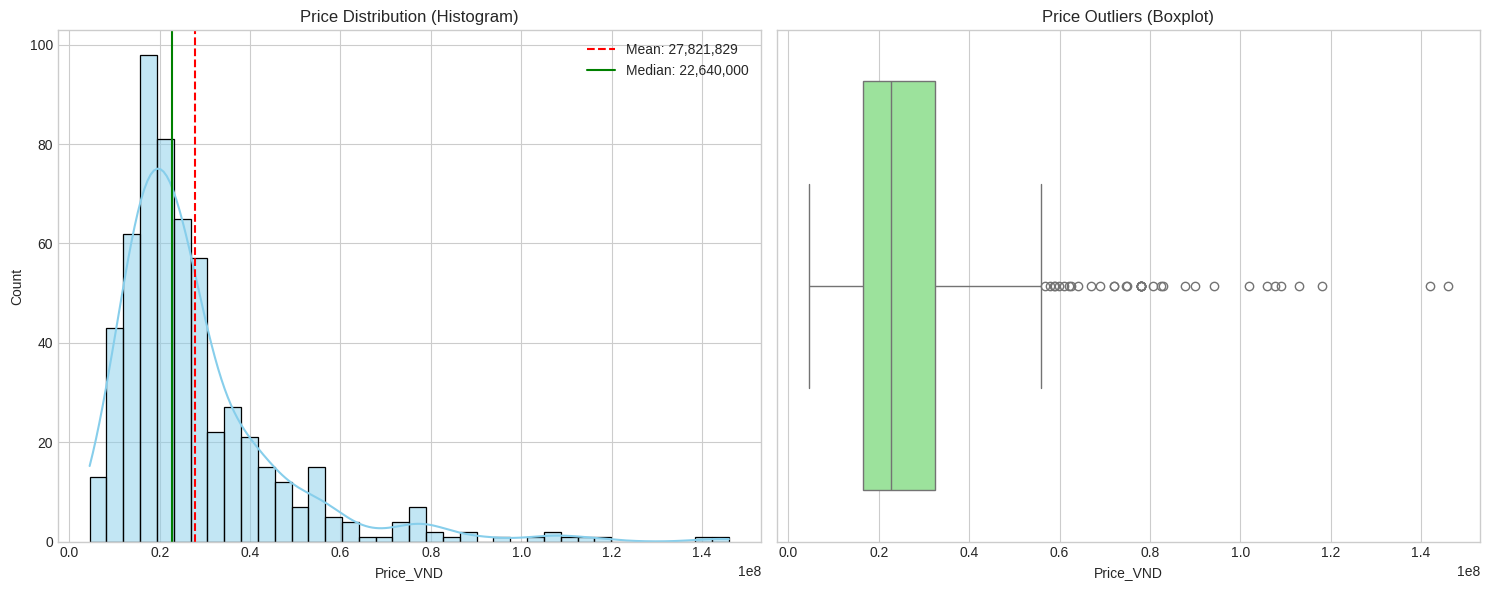

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Histogram with KDE
sns.histplot(price, kde=True, ax=ax[0], color='skyblue')
ax[0].axvline(mean_price, color='red', linestyle='--', label=f'Mean: {mean_price:,.0f}')
ax[0].axvline(median_price, color='green', linestyle='-', label=f'Median: {median_price:,.0f}')
ax[0].set_title('Price Distribution (Histogram)')
ax[0].legend()

# Boxplot
sns.boxplot(x=price, ax=ax[1], color='lightgreen')
ax[1].set_title('Price Outliers (Boxplot)')

plt.tight_layout()
plt.show()

---
# Part 3: Probability Theory (Lý thuyết xác suất)

Chúng ta sẽ tính toán xác suất thực nghiệm dựa trên tập dữ liệu.

### 3.1. Xác suất đơn (Marginal Probability)
Ví dụ: Xác suất để chọn ngẫu nhiên một laptop có RAM 16GB.

$$P(\text{RAM}=16\text{GB}) = \frac{\text{Số lượng laptop 16GB}}{\text{Tổng số laptop}}$$

### Questions:
1. Tính xác suất để chọn ngẫu nhiên một laptop có giá dưới 20 triệu VND.
2. Tính xác suất để chọn ngẫu nhiên một laptop có RAM 8GB.

In [35]:
total_laptops = len(df)
ram_16gb_count = len(df[df['RAM_GB'] == 16])

p_ram_16 = ram_16gb_count / total_laptops

print(f"Total laptops: {total_laptops}")
print(f"Laptops with 16GB RAM: {ram_16gb_count}")
print(f"P(RAM=16GB) = {p_ram_16:.4f} ({p_ram_16*100:.2f}%)")

Total laptops: 574
Laptops with 16GB RAM: 228
P(RAM=16GB) = 0.3972 (39.72%)


### 3.2. Xác suất có điều kiện (Conditional Probability)
Ví dụ: Xác suất để một laptop là dòng **Premium** (Giá > 40tr) BIẾT RẰNG nó có **Dedicated GPU**.

$$P(\text{Premium} \mid \text{Dedicated GPU}) = \frac{P(\text{Premium} \cap \text{Dedicated GPU})}{P(\text{Dedicated GPU})}$$

In [36]:
# Define events
event_A = df['Price_Segment'] == 'Premium'  # Event A: Laptop is Premium
event_B = df['GPU_Type'] == 'Dedicated'     # Event B: Laptop has Dedicated GPU

# Calculate probabilities
p_B = len(df[event_B]) / total_laptops
p_A_and_B = len(df[event_A & event_B]) / total_laptops

p_A_given_B = p_A_and_B / p_B

print(f"P(Dedicated GPU) = {p_B:.4f}")
print(f"P(Premium AND Dedicated GPU) = {p_A_and_B:.4f}")
print(f"P(Premium | Dedicated GPU) = {p_A_given_B:.4f} ({p_A_given_B*100:.2f}%)")

# Verification using subset
dedicated_gpu_df = df[event_B]
premium_in_dedicated = len(dedicated_gpu_df[dedicated_gpu_df['Price_Segment'] == 'Premium'])
print(f"Verification: {premium_in_dedicated}/{len(dedicated_gpu_df)} = {premium_in_dedicated/len(dedicated_gpu_df):.4f}")

P(Dedicated GPU) = 0.5819
P(Premium AND Dedicated GPU) = 0.1516
P(Premium | Dedicated GPU) = 0.2605 (26.05%)
Verification: 87/334 = 0.2605


---
# Part 4: Bayes' Theorem (Định lý Bayes)

Định lý Bayes cho phép chúng ta cập nhật xác suất của một giả thuyết khi có thêm bằng chứng mới.

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

**Bài toán:**
- **Giả thuyết (A):** Laptop là dòng **High-end** (25tr - 40tr).
- **Bằng chứng (B):** Laptop có **RAM 16GB**.

Chúng ta muốn tính $P(\text{High-end} \mid \text{RAM 16GB})$.

Theo Bayes:
$$P(\text{High-end} \mid \text{16GB}) = \frac{P(\text{16GB} \mid \text{High-end}) \cdot P(\text{High-end})}{P(\text{16GB})}$$

In [37]:
# Define Events
is_highend = df['Price_Segment'] == 'High-end'  # Event A
has_16gb = df['RAM_GB'] == 16                   # Event B

# 1. Prior Probability P(A): Xác suất laptop là High-end (khi chưa biết RAM)
p_highend = len(df[is_highend]) / total_laptops

# 2. Likelihood P(B|A): Xác suất có RAM 16GB NẾU nó là High-end
highend_laptops = df[is_highend]
p_16gb_given_highend = len(highend_laptops[highend_laptops['RAM_GB'] == 16]) / len(highend_laptops)

# 3. Marginal Probability P(B): Xác suất laptop có RAM 16GB (bất kể phân khúc)
p_16gb = len(df[has_16gb]) / total_laptops

# 4. Posterior Probability P(A|B) using Bayes Theorem
p_highend_given_16gb_bayes = (p_16gb_given_highend * p_highend) / p_16gb

print("--- Bayes' Theorem Calculation ---")
print(f"P(High-end) [Prior]          = {p_highend:.4f}")
print(f"P(16GB | High-end) [Likelihood]= {p_16gb_given_highend:.4f}")
print(f"P(16GB) [Evidence]           = {p_16gb:.4f}")
print(f"P(High-end | 16GB) [Posterior] = {p_highend_given_16gb_bayes:.4f}")

# Verification directly from data
laptops_16gb = df[has_16gb]
actual_prob = len(laptops_16gb[laptops_16gb['Price_Segment'] == 'High-end']) / len(laptops_16gb)
print(f"Actual P(High-end | 16GB)    = {actual_prob:.4f}")

--- Bayes' Theorem Calculation ---
P(High-end) [Prior]          = 0.2474
P(16GB | High-end) [Likelihood]= 0.6268
P(16GB) [Evidence]           = 0.3972
P(High-end | 16GB) [Posterior] = 0.3904
Actual P(High-end | 16GB)    = 0.3904


---
# Part 5: Probability Distributions (Phân phối xác suất)

Chúng ta sẽ kiểm tra xem dữ liệu `Price_VND` có tuân theo **Phân phối Chuẩn (Normal Distribution)** hay không.

Hàm mật độ xác suất (PDF) của phân phối chuẩn:
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_108873/129368081.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, p, 'k', linewidth=2, label=f'Normal Dist ($\mu$={mu/1e6:.1f}M, $\sigma$={std/1e6:.1f}M)')
/tmp/ipykernel_108873/129368081.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, p, 'k', linewidth=2, label=f'Normal Dist ($\mu$={mu/1e6:.1f}M, $\sigma$={std/1e6:.1f}M)')


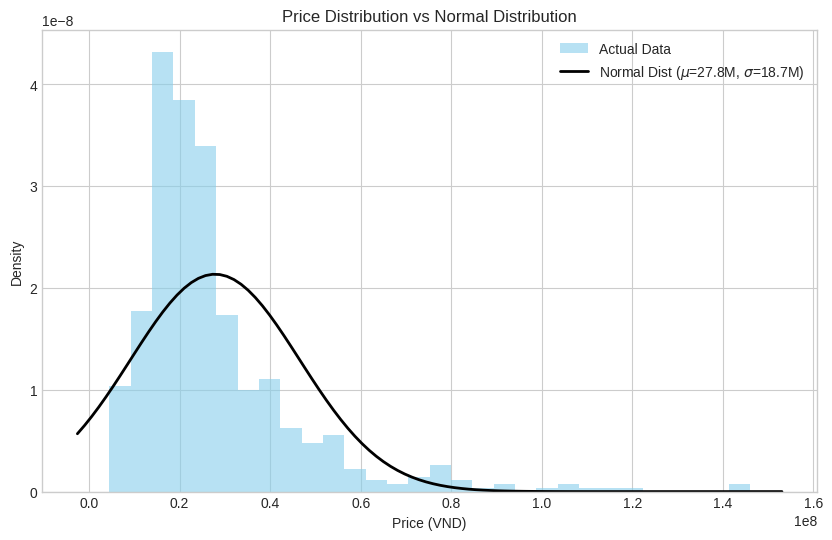

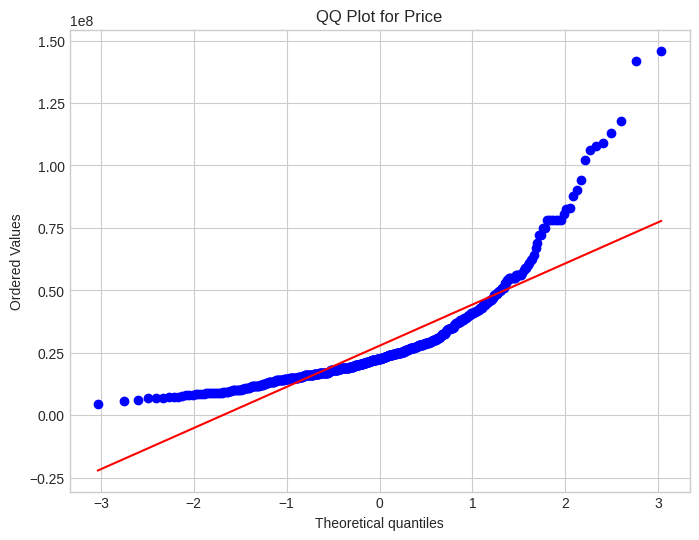

In [38]:
# Fit Normal Distribution to Price data
mu, std = stats.norm.fit(price)

# Plot Histogram vs Normal Curve
plt.figure(figsize=(10, 6))

# Plot histogram (density=True để chuẩn hóa diện tích về 1)
plt.hist(price, bins=30, density=True, alpha=0.6, color='skyblue', label='Actual Data')

# Plot Normal PDF
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Normal Dist ($\mu$={mu/1e6:.1f}M, $\sigma$={std/1e6:.1f}M)')

plt.title('Price Distribution vs Normal Distribution')
plt.xlabel('Price (VND)')
plt.ylabel('Density')
plt.legend()
plt.show()

# QQ Plot (Quantile-Quantile Plot) để kiểm tra độ chuẩn
plt.figure(figsize=(8, 6))
stats.probplot(price, dist="norm", plot=plt)
plt.title('QQ Plot for Price')
plt.show()

**Nhận xét:**
- Biểu đồ Histogram cho thấy dữ liệu bị lệch phải (Right-skewed).
- QQ Plot cho thấy các điểm dữ liệu không nằm thẳng hàng trên đường chéo, đặc biệt ở phần đuôi.
- $\rightarrow$ Dữ liệu giá laptop **không tuân theo phân phối chuẩn hoàn hảo**.

### Questions:
1. Tính xác suất để một laptop có giá nằm trong khoảng [15tr, 25tr] giả sử dữ liệu tuân theo phân phối chuẩn.
2. Tính Z-score của một laptop có giá 30 triệu VND.

In [39]:
# Question 1: P(15M <= Price <= 25M) assuming Normal Distribution
p_15m_25m = stats.norm.cdf(25000000, mu, std) - stats.norm.cdf(15000000, mu, std)
print(f"P(15M <= Price <= 25M) [Normal Assumption] = {p_15m_25m:.4f}")

# Question 2: Z-score of 30M
z_score_30m = (30000000 - mu) / std
print(f"Z-score of 30M = {z_score_30m:.4f}")

P(15M <= Price <= 25M) [Normal Assumption] = 0.1937
Z-score of 30M = 0.1166


---
# Part 6: Central Limit Theorem (Định lý giới hạn trung tâm)

**CLT phát biểu rằng:** Phân phối của các giá trị trung bình mẫu (sample means) sẽ tiến tới phân phối chuẩn khi kích thước mẫu (n) đủ lớn, bất kể phân phối gốc của dữ liệu là gì.

Chúng ta sẽ kiểm chứng điều này bằng cách:
1. Lấy $k=1000$ mẫu ngẫu nhiên từ dữ liệu Price.
2. Mỗi mẫu có kích thước $n=30$.
3. Tính trung bình cho từng mẫu và vẽ biểu đồ phân phối của các giá trị trung bình này.

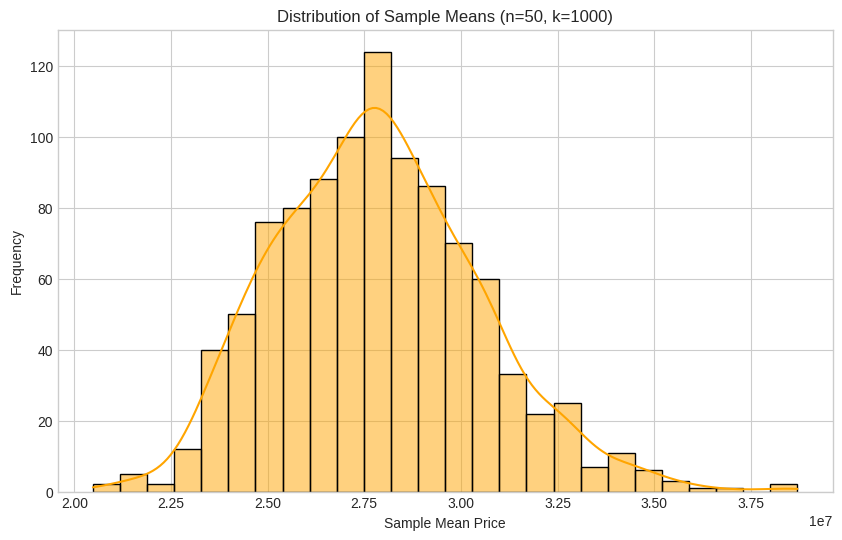

Shapiro-Wilk Test p-value: 0.0000
⚠️ Sample means deviate from Normal (Reject H0)


In [40]:
def central_limit_theorem_demo(data, sample_size, num_samples):
    sample_means = []
    for _ in range(num_samples):
        # Lấy mẫu ngẫu nhiên có hoàn lại (replace=True)
        sample = np.random.choice(data, size=sample_size, replace=True)
        sample_means.append(np.mean(sample))
    return sample_means

# Parameters
n = 50      # Sample size
k = 1000    # Number of samples

sample_means = central_limit_theorem_demo(price, n, k)

# Visualize
plt.figure(figsize=(10, 6))
sns.histplot(sample_means, kde=True, color='orange')
plt.title(f'Distribution of Sample Means (n={n}, k={k})')
plt.xlabel('Sample Mean Price')
plt.ylabel('Frequency')

# Fit Normal curve to sample means
mu_sample, std_sample = stats.norm.fit(sample_means)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu_sample, std_sample)
# Scale p to match histogram count if needed, or use density=True in histplot

plt.show()

# Shapiro-Wilk Test for Normality on Sample Means
shapiro_test = stats.shapiro(sample_means)
print(f"Shapiro-Wilk Test p-value: {shapiro_test.pvalue:.4f}")
if shapiro_test.pvalue > 0.05:
    print("✅ Sample means look Normal (Fail to reject H0)")
else:
    print("⚠️ Sample means deviate from Normal (Reject H0)")

### Questions:
1. Thử thay đổi kích thước mẫu $n=100$, phân phối của trung bình mẫu có thay đổi không?
2. Tính trung bình của các trung bình mẫu (Mean of Sample Means) và so sánh với trung bình tổng thể.

In [41]:
# Question 1: n=100
sample_means_100 = central_limit_theorem_demo(price, 100, 1000)
shapiro_test_100 = stats.shapiro(sample_means_100)
print(f"Shapiro-Wilk Test p-value (n=100): {shapiro_test_100.pvalue:.4f}")

# Question 2: Mean of Sample Means vs Population Mean
mean_of_sample_means = np.mean(sample_means)
print(f"Mean of Sample Means: {mean_of_sample_means:,.2f} VND")
print(f"Population Mean: {mean_price:,.2f} VND")
print(f"Difference: {abs(mean_of_sample_means - mean_price):,.2f} VND")

Shapiro-Wilk Test p-value (n=100): 0.0022
Mean of Sample Means: 27,855,312.20 VND
Population Mean: 27,821,829.27 VND
Difference: 33,482.93 VND


---
# Part 7: Confidence Intervals (Khoảng tin cậy)

Ước lượng khoảng giá trung bình của toàn bộ quần thể (population mean) dựa trên dữ liệu mẫu với độ tin cậy 95%.

$$CI = \bar{x} \pm Z \cdot \frac{\sigma}{\sqrt{n}}$$

Trong đó:
- $\bar{x}$: Trung bình mẫu.
- $Z$: Z-score tương ứng với độ tin cậy (1.96 cho 95%).
- $\sigma$: Độ lệch chuẩn mẫu (hoặc quần thể).
- $n$: Kích thước mẫu.

In [42]:
# Calculate 95% Confidence Interval for the Mean Price
confidence_level = 0.95
degrees_freedom = len(price) - 1
sample_mean = np.mean(price)
sample_standard_error = stats.sem(price)  # Standard Error of Mean (sigma / sqrt(n))

# Using t-distribution because we don't know population std dev
confidence_interval = stats.t.interval(
    confidence_level, 
    degrees_freedom, 
    loc=sample_mean, 
    scale=sample_standard_error
)

print(f"Mean Price: {sample_mean:,.0f} VND")
print(f"95% Confidence Interval: ({confidence_interval[0]:,.0f}, {confidence_interval[1]:,.0f}) VND")
print(f"Margin of Error: {(confidence_interval[1] - sample_mean):,.0f} VND")

print("\nInterpretation:")
print(f"Chúng ta tin cậy 95% rằng giá trung bình thực sự của các laptop ASUS nằm trong khoảng từ {confidence_interval[0]/1e6:.1f} triệu đến {confidence_interval[1]/1e6:.1f} triệu VND.")

Mean Price: 27,821,829 VND
95% Confidence Interval: (26,288,703, 29,354,956) VND
Margin of Error: 1,533,127 VND

Interpretation:
Chúng ta tin cậy 95% rằng giá trung bình thực sự của các laptop ASUS nằm trong khoảng từ 26.3 triệu đến 29.4 triệu VND.


### Questions:
1. Tính khoảng tin cậy 99% cho giá trung bình.
2. Tính khoảng tin cậy 95% cho RAM trung bình.

In [43]:
# Question 1: 99% CI for Price
ci_99 = stats.t.interval(0.99, degrees_freedom, loc=sample_mean, scale=sample_standard_error)
print(f"99% CI for Price: ({ci_99[0]:,.0f}, {ci_99[1]:,.0f}) VND")

# Question 2: 95% CI for RAM
ram = df['RAM_GB']
ram_mean = np.mean(ram)
ram_sem = stats.sem(ram)
ci_ram_95 = stats.t.interval(0.95, len(ram)-1, loc=ram_mean, scale=ram_sem)
print(f"95% CI for RAM: ({ci_ram_95[0]:.2f}, {ci_ram_95[1]:.2f}) GB")

99% CI for Price: (25,804,497, 29,839,162) VND
95% CI for RAM: (14.01, 15.76) GB


---
# Part 8: Hypothesis Testing (Kiểm định giả thuyết)

Chúng ta sẽ thực hiện kiểm định T-test để so sánh giá trung bình giữa hai nhóm laptop: **Dedicated GPU** (Card rời) và **Integrated GPU** (Card tích hợp).

- $H_0$: Giá trung bình của hai nhóm bằng nhau ($\mu_1 = \mu_2$).
- $H_1$: Giá trung bình của nhóm Dedicated GPU cao hơn nhóm Integrated GPU ($\mu_1 > \mu_2$).

In [44]:
# Prepare data
dedicated_prices = df[df['GPU_Type'] == 'Dedicated']['Price_VND']
integrated_prices = df[df['GPU_Type'] == 'Integrated']['Price_VND']

print(f"Dedicated GPU: n={len(dedicated_prices)}, Mean={dedicated_prices.mean():,.0f} VND")
print(f"Integrated GPU: n={len(integrated_prices)}, Mean={integrated_prices.mean():,.0f} VND")

# Perform Independent T-test (assuming unequal variances - Welch's t-test)
t_stat, p_val = stats.ttest_ind(dedicated_prices, integrated_prices, equal_var=False, alternative='greater')

print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

alpha = 0.05
if p_val < alpha:
    print("\n✅ Reject H0: Có bằng chứng thống kê đủ mạnh để khẳng định giá laptop Card rời CAO HƠN Card tích hợp.")
else:
    print("\n⚠️ Fail to reject H0: Chưa đủ bằng chứng để khẳng định sự khác biệt.")

Dedicated GPU: n=334, Mean=33,898,563 VND
Integrated GPU: n=239, Mean=19,405,941 VND

T-statistic: 11.0538
P-value: 8.0714e-26

✅ Reject H0: Có bằng chứng thống kê đủ mạnh để khẳng định giá laptop Card rời CAO HƠN Card tích hợp.


### Questions:
1. Thực hiện kiểm định T-test so sánh RAM trung bình giữa nhóm **Budget** và **Premium**.
2. Thực hiện kiểm định T-test so sánh giá trung bình giữa nhóm **Core i5** và **Core i7**.

In [45]:
# Question 1: T-test RAM Budget vs Premium
ram_budget = df[df['Price_Segment'] == 'Budget']['RAM_GB']
ram_premium = df[df['Price_Segment'] == 'Premium']['RAM_GB']
t_stat_ram, p_val_ram = stats.ttest_ind(ram_budget, ram_premium, equal_var=False)
print(f"T-test RAM (Budget vs Premium) p-value: {p_val_ram:.4e}")

# Question 2: T-test Price Core i5 vs Core i7
def is_cpu(cpu_str, type_str):
    return type_str in str(cpu_str).lower()

price_i5 = df[df['CPU'].apply(lambda x: is_cpu(x, 'core i5'))]['Price_VND']
price_i7 = df[df['CPU'].apply(lambda x: is_cpu(x, 'core i7'))]['Price_VND']
t_stat_cpu, p_val_cpu = stats.ttest_ind(price_i5, price_i7, equal_var=False)
print(f"T-test Price (Core i5 vs Core i7) p-value: {p_val_cpu:.4e}")

T-test RAM (Budget vs Premium) p-value: 4.2279e-23
T-test Price (Core i5 vs Core i7) p-value: 1.7780e-17


---
# Part 9: Correlation Analysis (Phân tích tương quan)

Kiểm tra mối quan hệ tuyến tính giữa **RAM** và **Giá**.

Pearson Correlation (r): 0.7640
P-value: 6.2860e-111
✅ Tương quan có ý nghĩa thống kê.


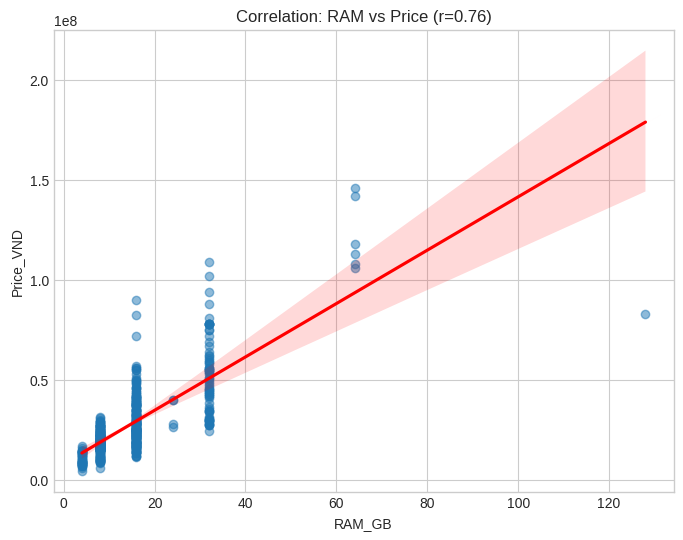

In [46]:
# Calculate Pearson Correlation
corr_coef, p_val_corr = stats.pearsonr(df['RAM_GB'], df['Price_VND'])

print(f"Pearson Correlation (r): {corr_coef:.4f}")
print(f"P-value: {p_val_corr:.4e}")

if p_val_corr < 0.05:
    print("✅ Tương quan có ý nghĩa thống kê.")
else:
    print("⚠️ Tương quan không có ý nghĩa thống kê.")

# Visualize
plt.figure(figsize=(8, 6))
sns.regplot(x='RAM_GB', y='Price_VND', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'Correlation: RAM vs Price (r={corr_coef:.2f})')
plt.show()

### Questions:
1. Tính hệ số tương quan giữa **Storage** (nếu có) và **Price**.
2. Tính hệ số tương quan giữa **RAM** và **Storage**.

In [47]:
# Preprocess Storage first (need to extract numeric value)
def clean_storage(storage_str):
    if pd.isna(storage_str): return np.nan
    storage_str = str(storage_str).upper()
    tb_match = re.search(r'(\d+)\s*TB', storage_str)
    if tb_match:
        return float(tb_match.group(1)) * 1024
    gb_match = re.search(r'(\d+)\s*GB', storage_str)
    if gb_match:
        return float(gb_match.group(1))
    return np.nan

df['Storage_GB'] = df['Storage'].apply(clean_storage)
df_clean_storage = df.dropna(subset=['Storage_GB'])

# Question 1: Correlation Storage vs Price
corr_storage_price, p_storage_price = stats.pearsonr(df_clean_storage['Storage_GB'], df_clean_storage['Price_VND'])
print(f"Correlation Storage vs Price: {corr_storage_price:.4f}")

# Question 2: Correlation RAM vs Storage
corr_ram_storage, p_ram_storage = stats.pearsonr(df_clean_storage['RAM_GB'], df_clean_storage['Storage_GB'])
print(f"Correlation RAM vs Storage: {corr_ram_storage:.4f}")

Correlation Storage vs Price: 0.5824
Correlation RAM vs Storage: 0.5343


---
# Part 10: Advanced Bayes Application

**Câu hỏi:** Nếu một chiếc laptop sử dụng chip **Intel Core i9**, xác suất nó thuộc phân khúc **Premium** (>40tr) là bao nhiêu?

$$P(\text{Premium} \mid \text{Core i9}) = \frac{P(\text{Core i9} \mid \text{Premium}) \cdot P(\text{Premium})}{P(\text{Core i9})}$$

In [48]:
# Define Events
def is_core_i9(cpu_str):
    return 'core i9' in str(cpu_str).lower() or 'core 9' in str(cpu_str).lower()

df['Is_Core_i9'] = df['CPU'].apply(is_core_i9)

event_Premium = df['Price_Segment'] == 'Premium'
event_i9 = df['Is_Core_i9']

# Calculate components
p_Premium = len(df[event_Premium]) / len(df)
p_i9 = len(df[event_i9]) / len(df)

premium_laptops = df[event_Premium]
p_i9_given_Premium = len(premium_laptops[premium_laptops['Is_Core_i9']]) / len(premium_laptops)

# Bayes Calculation
if p_i9 > 0:
    p_Premium_given_i9 = (p_i9_given_Premium * p_Premium) / p_i9
    print(f"P(Premium) = {p_Premium:.4f}")
    print(f"P(Core i9) = {p_i9:.4f}")
    print(f"P(Core i9 | Premium) = {p_i9_given_Premium:.4f}")
    print(f"P(Premium | Core i9) = {p_Premium_given_i9:.4f} ({p_Premium_given_i9*100:.1f}%)")
else:
    print("No Core i9 laptops in dataset.")

P(Premium) = 0.1638
P(Core i9) = 0.0314
P(Core i9 | Premium) = 0.1596
P(Premium | Core i9) = 0.8333 (83.3%)


### Questions:
1. Tính xác suất laptop là dòng **High-end** biết rằng nó sử dụng chip **Core i7**.
2. Tính xác suất laptop là dòng **Budget** biết rằng nó sử dụng chip **Core i3**.

In [49]:
# Helper function for Bayes
def calculate_bayes(df, event_A_col, event_A_val, event_B_col, event_B_func):
    # P(A|B) = P(B|A) * P(A) / P(B)
    event_A = df[event_A_col] == event_A_val
    event_B = df[event_B_col].apply(event_B_func)
    
    p_A = len(df[event_A]) / len(df)
    p_B = len(df[event_B]) / len(df)
    
    df_A = df[event_A]
    p_B_given_A = len(df_A[df_A[event_B_col].apply(event_B_func)]) / len(df_A)
    
    if p_B == 0: return 0
    return (p_B_given_A * p_A) / p_B

# Question 1: P(High-end | Core i7)
p_highend_i7 = calculate_bayes(df, 'Price_Segment', 'High-end', 'CPU', lambda x: 'core i7' in str(x).lower())
print(f"P(High-end | Core i7) = {p_highend_i7:.4f}")

# Question 2: P(Budget | Core i3)
p_budget_i3 = calculate_bayes(df, 'Price_Segment', 'Budget', 'CPU', lambda x: 'core i3' in str(x).lower())
print(f"P(Budget | Core i3) = {p_budget_i3:.4f}")

P(High-end | Core i7) = 0.5625
P(Budget | Core i3) = 1.0000


---
# Part 11: Log-Normal Distribution Check

Vì dữ liệu giá bị lệch phải, chúng ta thử biến đổi Logarit xem dữ liệu có tuân theo phân phối chuẩn không.

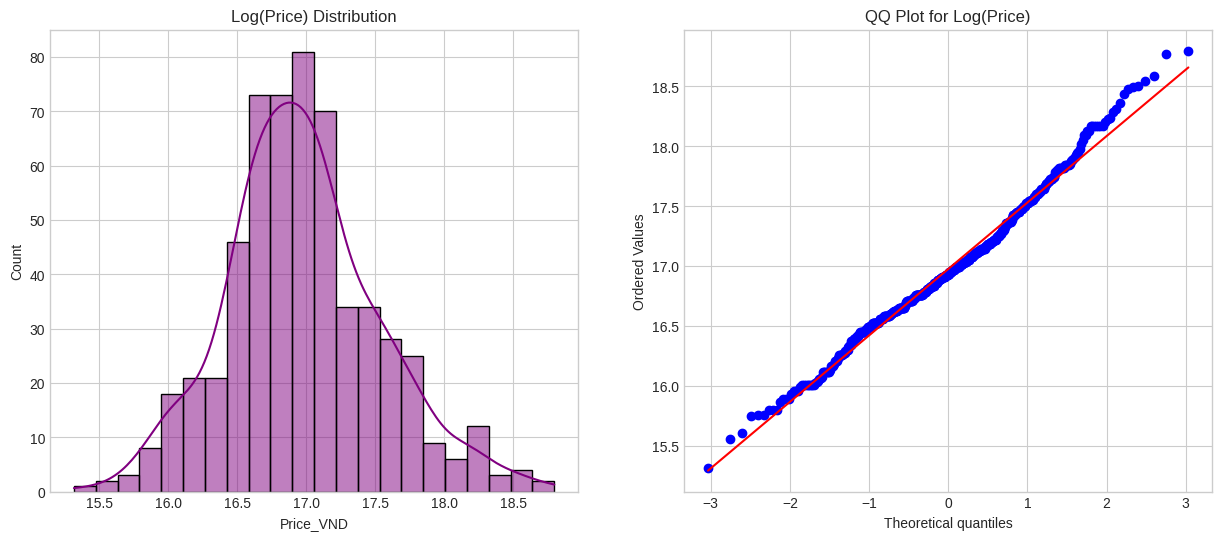

Shapiro-Wilk Test for Log(Price) p-value: 2.0392e-04
⚠️ Log(Price) still deviates from Normal, but looks better visually.


In [50]:
log_price = np.log(df['Price_VND'])

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of Log-Price
sns.histplot(log_price, kde=True, ax=ax[0], color='purple')
ax[0].set_title('Log(Price) Distribution')

# QQ Plot of Log-Price
stats.probplot(log_price, dist="norm", plot=ax[1])
ax[1].set_title('QQ Plot for Log(Price)')

plt.show()

shapiro_log = stats.shapiro(log_price)
print(f"Shapiro-Wilk Test for Log(Price) p-value: {shapiro_log.pvalue:.4e}")
if shapiro_log.pvalue > 0.05:
    print("✅ Log(Price) follows Normal Distribution.")
else:
    print("⚠️ Log(Price) still deviates from Normal, but looks better visually.")

### Questions:
1. Thử biến đổi Box-Cox thay vì Logarit và kiểm tra tính chuẩn.
2. So sánh Skewness của dữ liệu gốc, Log-transformed và Box-Cox transformed.

In [51]:
# Question 1: Box-Cox Transformation
price_boxcox, lam = stats.boxcox(df['Price_VND'])
print(f"Box-Cox Lambda: {lam:.4f}")
shapiro_boxcox = stats.shapiro(price_boxcox)
print(f"Shapiro-Wilk Test (Box-Cox) p-value: {shapiro_boxcox.pvalue:.4e}")

# Question 2: Compare Skewness
skew_orig = stats.skew(df['Price_VND'])
skew_log = stats.skew(log_price)
skew_boxcox = stats.skew(price_boxcox)

print(f"Skewness (Original): {skew_orig:.4f}")
print(f"Skewness (Log): {skew_log:.4f}")
print(f"Skewness (Box-Cox): {skew_boxcox:.4f}")

Box-Cox Lambda: -0.1872
Shapiro-Wilk Test (Box-Cox) p-value: 5.2408e-02
Skewness (Original): 2.4756
Skewness (Log): 0.3439
Skewness (Box-Cox): -0.0088


---
# Kết luận

Qua bài lab này, chúng ta đã áp dụng các khái niệm xác suất thống kê vào dữ liệu thực tế:

1. **Phân phối giá:** Giá laptop ASUS lệch phải, tập trung nhiều ở phân khúc 15-25 triệu.
2. **Bayes:** Đã tính toán được xác suất một laptop là High-end khi biết nó có 16GB RAM, cho thấy RAM là một chỉ báo tốt cho phân khúc giá.
3. **CLT:** Đã kiểm chứng rằng dù phân phối gốc lệch, phân phối của trung bình mẫu vẫn tuân theo phân phối chuẩn.
4. **Confidence Interval:** Đưa ra được khoảng ước lượng cho giá trung bình với độ tin cậy cao.
5. **Hypothesis Testing:** Xác nhận sự khác biệt có ý nghĩa thống kê về giá giữa laptop có Card rời và Card tích hợp.
6. **Correlation:** Tìm thấy mối tương quan giữa RAM và Giá.
7. **Advanced Bayes:** Áp dụng Bayes cho các bài toán phức tạp hơn (Core i9 -> Premium).
8. **Transformations:** Log-transform và Box-Cox giúp dữ liệu gần với phân phối chuẩn hơn.

**Sinh viên:** 523H0164
**Ngày:** 20/11/2025